In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from plottable import Table, ColumnDefinition
from plottable.cmap import normed_cmap

In [56]:
df=pd.read_csv('Polonia Bytom_Pogo  Grodzisk Mazowiecki_4068759.csv')

df = df.drop_duplicates(subset='id').reset_index(drop=True) # usuwanie freeze frame, bo tutaj skupiamy sie na samych eventach

In [57]:
team_A=35036 #Pogoń Grodzisk Mazowiecki
team_B=35037 #Polonia Bytom

df['goal_A'] = ((df['outcome_name']=='Goal') & (df['team_id']==team_A)).astype(int)
df['goal_B'] = ((df['outcome_name']=='Goal') & (df['team_id']==team_B)).astype(int)

df['score_A'] = df['goal_A'].cumsum()
df['score_B'] = df['goal_B'].cumsum()

df['score_ratio']=(df['score_A']- df['score_B']).shift(1).fillna(0).astype(int)



In [58]:
df.tail()

,id,index,match_id,period,timestamp,minute,second,event_type_id,event_type_name,possession,...,is_transition,is_controlled_possession,player_possession_directness,possession_directness,location_bucket,goal_A,goal_B,score_A,score_B,score_ratio
3227,33652af7-5c6e-566d-82ab-53d3a210f112,3228,4068759,2,00:48:54.894,93,54,1000,Offensive Duel,214,...,NaN,NaN,NaN,NaN,defensive_third,0,0,2,2,0
3228,f2c43647-5931-4695-8cdc-67b07d0de757,3229,4068759,2,00:48:55.014,93,55,22,Foul Committed,214,...,NaN,NaN,NaN,NaN,final_third,0,0,2,2,0
3229,4779ec4f-24b7-50d4-9bbd-542f9ab5f709,3230,4068759,2,00:48:55.014,93,55,21,Foul Won,214,...,True,False,0.174364,NaN,defensive_third,0,0,2,2,0
3230,378cfbd5-0f7e-4f1c-8c90-a76f35c7e764,3231,4068759,2,00:49:19.860,94,19,34,Half End,215,...,NaN,NaN,NaN,NaN,NaN,0,0,2,2,0
3231,d238bc2d-f543-5f1d-a341-b38ddeadcff3,3232,4068759,2,00:49:19.860,94,19,34,Half End,215,...,NaN,NaN,NaN,NaN,NaN,0,0,2,2,0


In [59]:
shots=df[df['event_type_name']=='Shot'].drop_duplicates(subset='id').copy()

In [60]:
shots['diff_persp'] = np.where(shots['team_id']==team_A, shots['score_ratio'], shots['score_ratio'] * -1)

shots['state_ratio']=shots['diff_persp'].apply(lambda x: "tie" if x==0 else ("losing" if x<0 else "winning"))

In [61]:
table=shots.pivot_table(index='team_name',
                  columns='state_ratio',
                  values='statsbomb_xg',
                  aggfunc='sum',
                  fill_value=0).round(3)

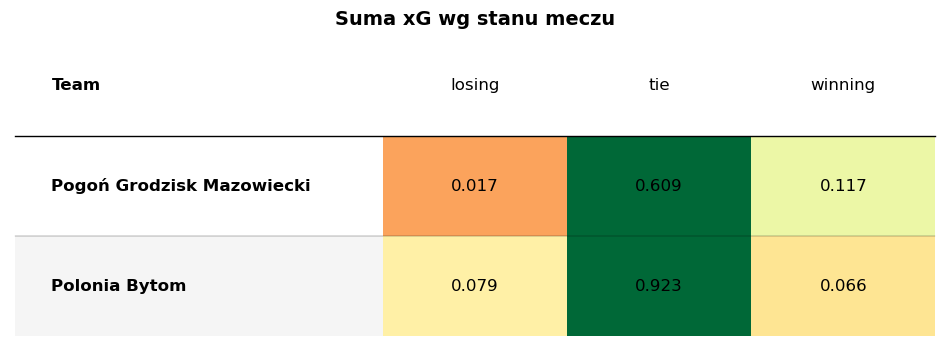

In [62]:
df_table = table.copy()
df_table = df_table.reset_index()
df_table = df_table.rename(columns={df_table.columns[0]: 'Team'})

all_vals = pd.concat([df_table['losing'], df_table['tie'], df_table['winning']])
shared_cmap = normed_cmap(all_vals, cmap=matplotlib.cm.RdYlGn, num_stds=0.5)

col_defs = [
    ColumnDefinition(name='Team', textprops={'ha': 'left','weight':'bold'}, width=2.0),
    ColumnDefinition(name='losing', textprops={'ha': 'center'},
                     cmap=shared_cmap, formatter='{:.3f}'),
    ColumnDefinition(name='tie', textprops={'ha': 'center'},
                     cmap=shared_cmap, formatter='{:.3f}'),
    ColumnDefinition(name='winning', textprops={'ha': 'center'},
                     cmap=shared_cmap, formatter='{:.3f}'),
]

fig, ax = plt.subplots(figsize=(12, 4))
fig.set_facecolor('white')

tab = Table(
    df_table,
    column_definitions=col_defs, 
    index_col='Team',
    row_dividers=True,
    odd_row_color='#f5f5f5',
    even_row_color='white',
    textprops={'fontsize': 12},
    ax=ax,
)

plt.title('Suma xG wg stanu meczu', fontsize=14, fontweight='bold')
plt.show()

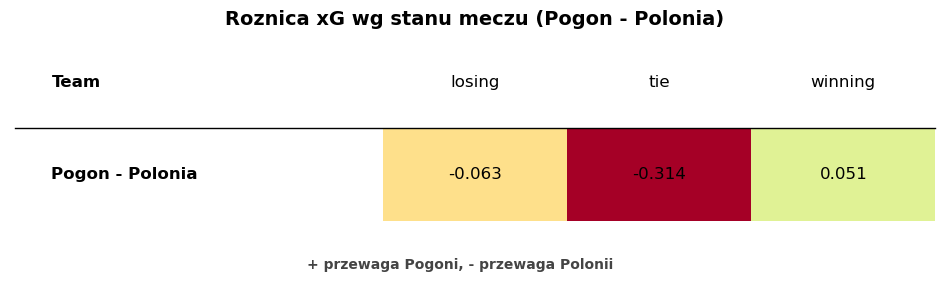

In [65]:
common = shots.pivot_table(index='team_name', columns='state_ratio',
                           values='statsbomb_xg', aggfunc='sum', fill_value=0)

diff = common.loc['Pogoń Grodzisk Mazowiecki'] - common.loc['Polonia Bytom']
diff_table = pd.DataFrame([diff.values],
                          columns=['losing', 'tie', 'winning'],
                          index=['Pogon - Polonia'])
diff_table = diff_table.reset_index().rename(columns={'index': 'Team'})

vals = diff_table[['losing','tie','winning']].values
m = abs(vals).max()   # zeby skala byla symetryczna wokol zera

def diff_cmap(name):
    norm = matplotlib.colors.TwoSlopeNorm(vmin=-m, vcenter=0, vmax=m)
    return lambda v: matplotlib.cm.RdYlGn(norm(v))

col_defs = [
    ColumnDefinition(name='Team', textprops={'ha':'left','weight':'bold'}, width=2.0),
    ColumnDefinition(name='losing', textprops={'ha':'center'},
                     cmap=diff_cmap('losing'), formatter='{:.3f}'),
    ColumnDefinition(name='tie', textprops={'ha':'center'},
                     cmap=diff_cmap('tie'), formatter='{:.3f}'),
    ColumnDefinition(name='winning', textprops={'ha':'center'},
                     cmap=diff_cmap('winning'), formatter='{:.3f}'),
]

fig, ax = plt.subplots(figsize=(12, 2.5))
fig.set_facecolor('white')
Table(diff_table, column_definitions=col_defs, index_col='Team',
      row_dividers=True, odd_row_color='#f5f5f5', even_row_color='white',
      textprops={'fontsize':12}, ax=ax)
plt.title('Roznica xG wg stanu meczu (Pogon - Polonia)', fontsize=14, fontweight='bold')

fig.text(
    0.5, -0.02,
    '+ przewaga Pogoni, - przewaga Polonii',
    ha='center', va='top', fontsize=10, color='#444444', fontweight='bold'
)

plt.show()